# Time-Series Analysis

In [2]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 11.3 MB/s  0:00:01 eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] 4/5 [statsmodels]


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

from statsmodels.tsa.stattools import (
    adfuller,
    kpss
)

from statsmodels.tsa.seasonal import STL

from statsmodels.stats.diagnostic import (
    acorr_ljungbox
)

pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / "phase5_time_series"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
hourly = pd.read_csv(
    PROCESSED_DIR / "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [6]:
daily = pd.read_csv(
    PROCESSED_DIR / "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [7]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly frequency:",
    pd.infer_freq(hourly.index)
)

print(
    "Daily frequency:",
    pd.infer_freq(daily.index)
)

print(
    "Missing hourly values:",
    hourly['pm25'].isna().sum()
)

print(
    "Missing daily values:",
    daily['pm25_mean'].isna().sum()
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly frequency: h
Daily frequency: D
Missing hourly values: 0
Missing daily values: 0


In [8]:
#two PM2.5 series
hourly_pm25 = (
    hourly['pm25']
    .astype(float)
    .copy()
)

daily_pm25 = (
    daily['pm25_mean']
    .astype(float)
    .copy()
)

In [9]:
print(hourly_pm25.describe())
print()
print(daily_pm25.describe())

count    23352.000000
mean        35.045422
std         23.252260
min          0.200000
25%         18.800000
50%         29.000000
75%         44.600000
max        170.400000
Name: pm25, dtype: float64

count    973.000000
mean      35.045422
std       19.090764
min        0.583333
25%       20.112500
50%       30.791667
75%       45.683333
max      119.158333
Name: pm25_mean, dtype: float64


In [10]:
#Hourly PM2.5 persistence

hourly_lags = [
    1,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

In [12]:
#correlation
hourly_lag_correlations = {}

for lag in hourly_lags:

    correlation = hourly_pm25.corr(
        hourly_pm25.shift(lag)
    )

    hourly_lag_correlations[lag] = correlation


hourly_lag_correlations = pd.Series(
    hourly_lag_correlations,
    name='correlation'
).to_frame()

hourly_lag_correlations.index.name = 'lag_hours'

hourly_lag_correlations

,correlation
lag_hours,
1,0.964568
3,0.847723
6,0.666240
12,0.461233
24,0.876913
48,0.801338
72,0.752890
168,0.686989


In [13]:
hourly_lag_correlations['description'] = [
    '1 hour',
    '3 hours',
    '6 hours',
    '12 hours',
    '1 day',
    '2 days',
    '3 days',
    '1 week'
]

hourly_lag_correlations

,correlation,description
lag_hours,,
1,0.964568,1 hour
3,0.847723,3 hours
6,0.666240,6 hours
12,0.461233,12 hours
24,0.876913,1 day
48,0.801338,2 days
72,0.752890,3 days
168,0.686989,1 week


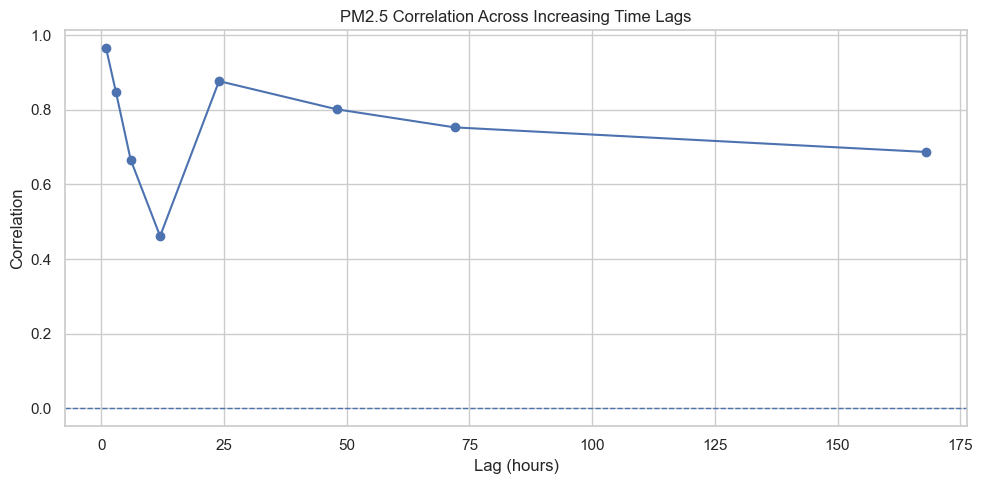

In [14]:
#lag correlation decay
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_lag_correlations.index,
    hourly_lag_correlations['correlation'],
    marker='o'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title(
    'PM2.5 Correlation Across Increasing Time Lags'
)

plt.xlabel('Lag (hours)')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()

## Daily persistence
Hourly measurements are strongly related partly because adjacent observations are only an hour apart.
Daily persistence gives a broader picture.

In [16]:
#Daily lag correlations
daily_lags = [
    1,
    2,
    3,
    7,
    14,
    30,
    60
]

In [17]:
daily_lag_correlations = {}

for lag in daily_lags:

    correlation = daily_pm25.corr(
        daily_pm25.shift(lag)
    )

    daily_lag_correlations[lag] = correlation


daily_lag_correlations = pd.Series(
    daily_lag_correlations,
    name='correlation'
).to_frame()

daily_lag_correlations.index.name = 'lag_days'

daily_lag_correlations

,correlation
lag_days,
1,0.918549
2,0.813737
3,0.751077
7,0.655727
14,0.667347
30,0.556985
60,0.329733


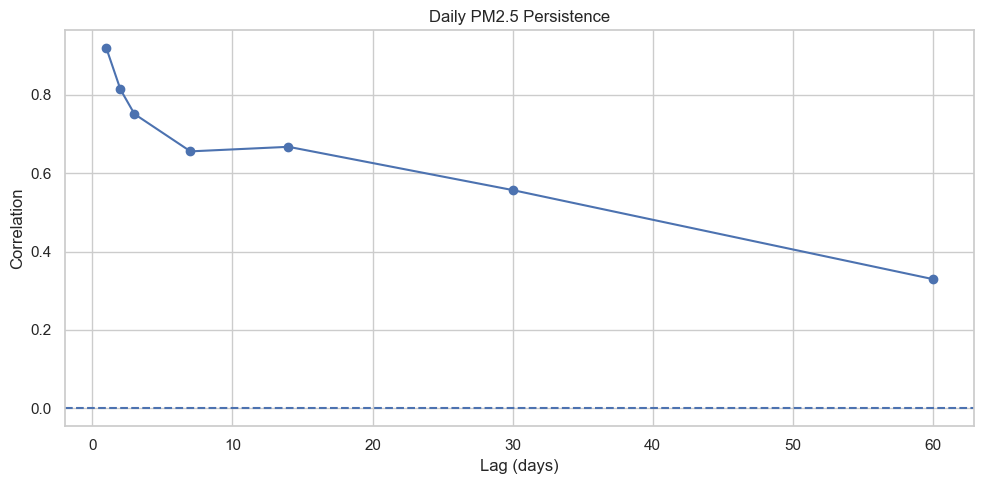

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_lag_correlations.index,
    daily_lag_correlations['correlation'],
    marker='o'
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Daily PM2.5 Persistence'
)

plt.xlabel('Lag (days)')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()

## Autocorrelation Function

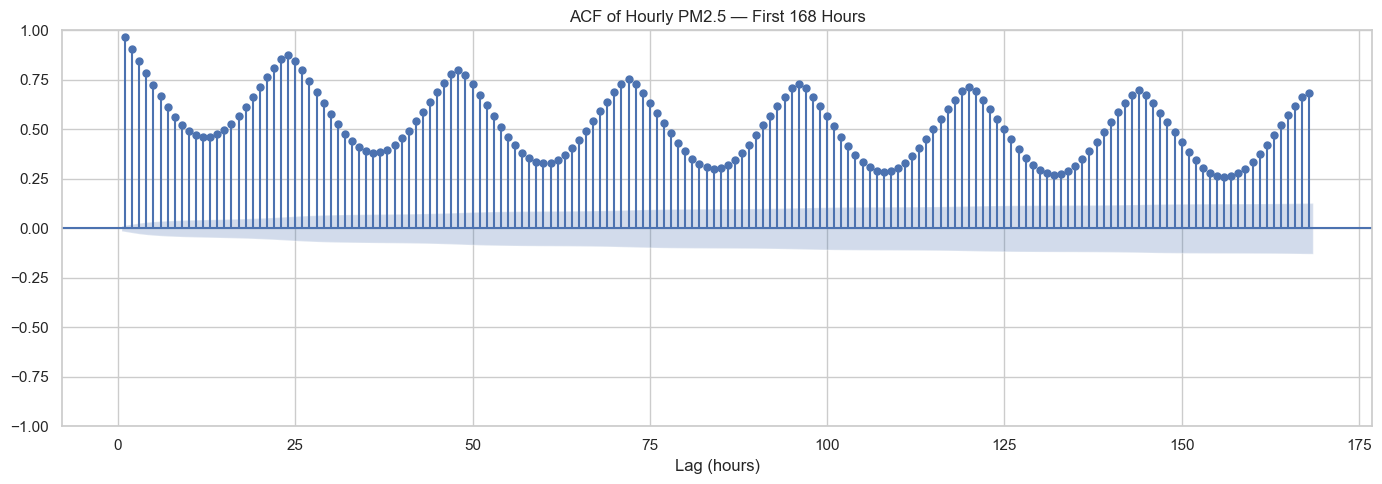

In [19]:
#Hourly ACF

fig, ax = plt.subplots(
    figsize=(14, 5)
)

plot_acf(
    hourly_pm25,
    lags=168,
    zero=False,
    ax=ax
)

ax.set_title(
    'ACF of Hourly PM2.5 — First 168 Hours'
)

ax.set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

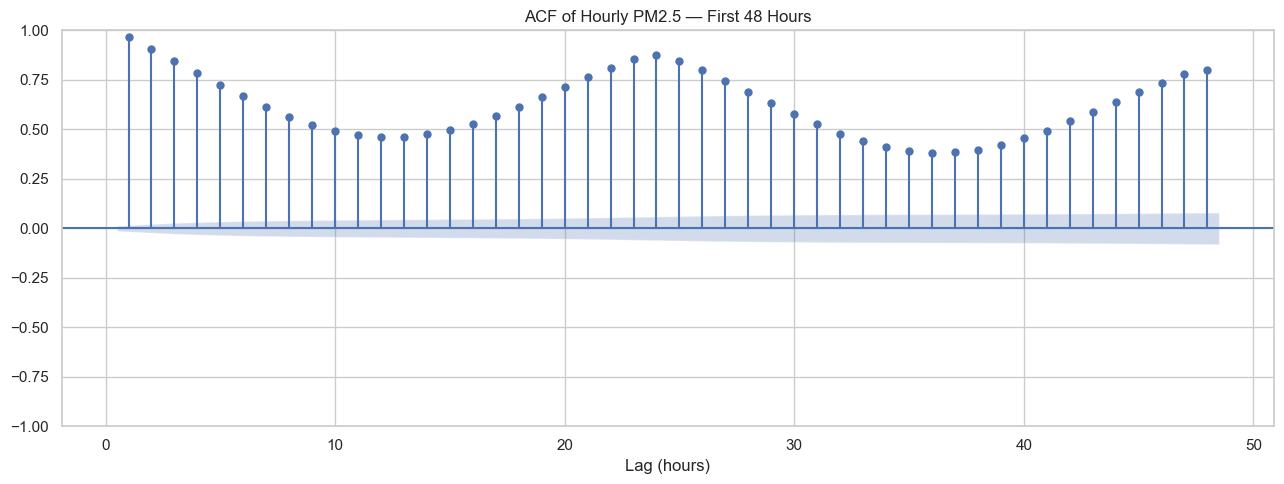

In [20]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

plot_acf(
    hourly_pm25,
    lags=48,
    zero=False,
    ax=ax
)

ax.set_title(
    'ACF of Hourly PM2.5 — First 48 Hours'
)

ax.set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

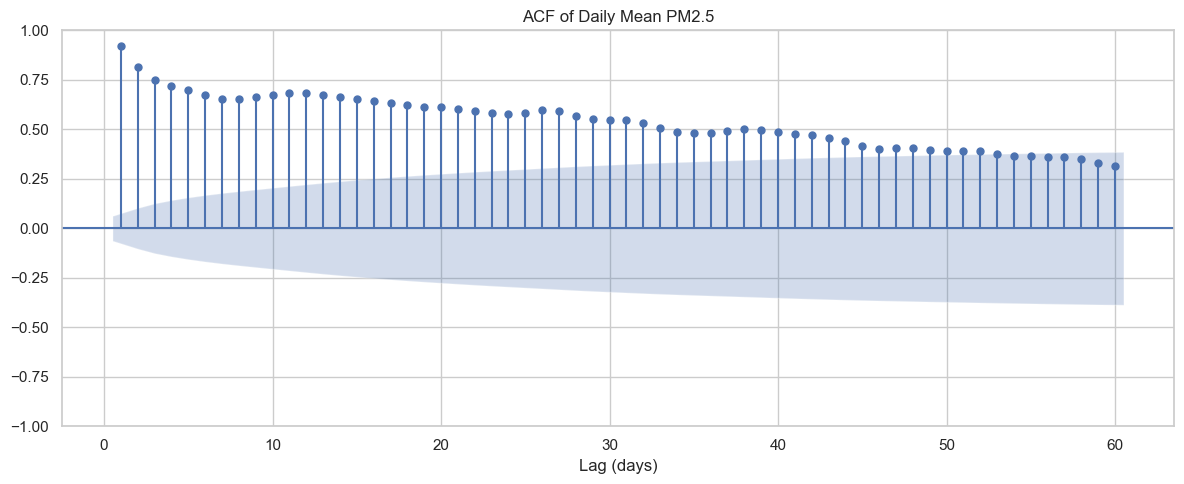

In [21]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_acf(
    daily_pm25,
    lags=60,
    zero=False,
    ax=ax
)

ax.set_title(
    'ACF of Daily Mean PM2.5'
)

ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

## Partial Autocorrelation

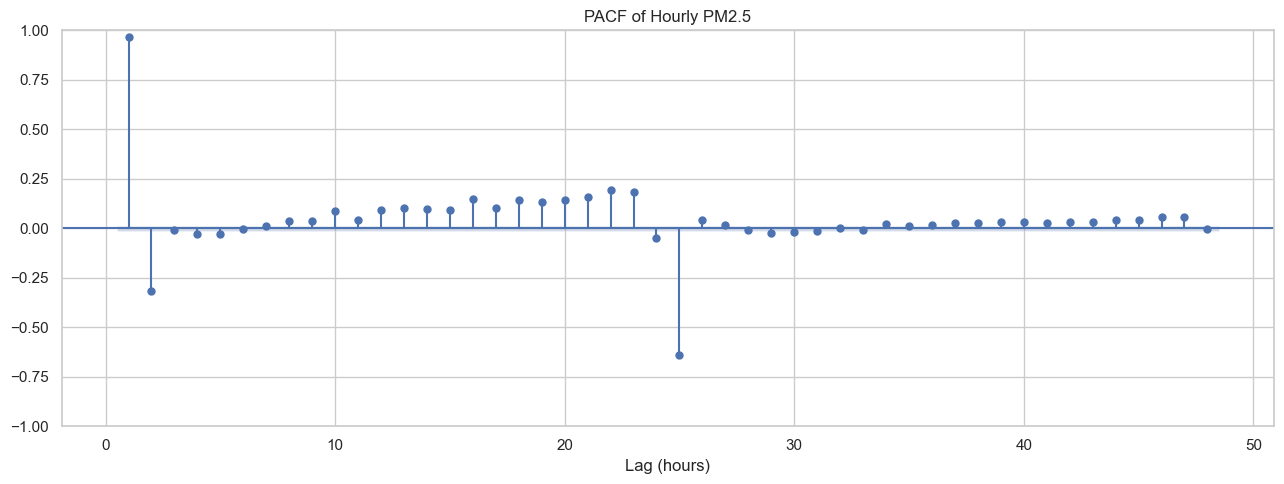

In [22]:
#Hourly PACF
fig, ax = plt.subplots(
    figsize=(13, 5)
)

plot_pacf(
    hourly_pm25,
    lags=48,
    method='ywm',
    zero=False,
    ax=ax
)

ax.set_title(
    'PACF of Hourly PM2.5'
)

ax.set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

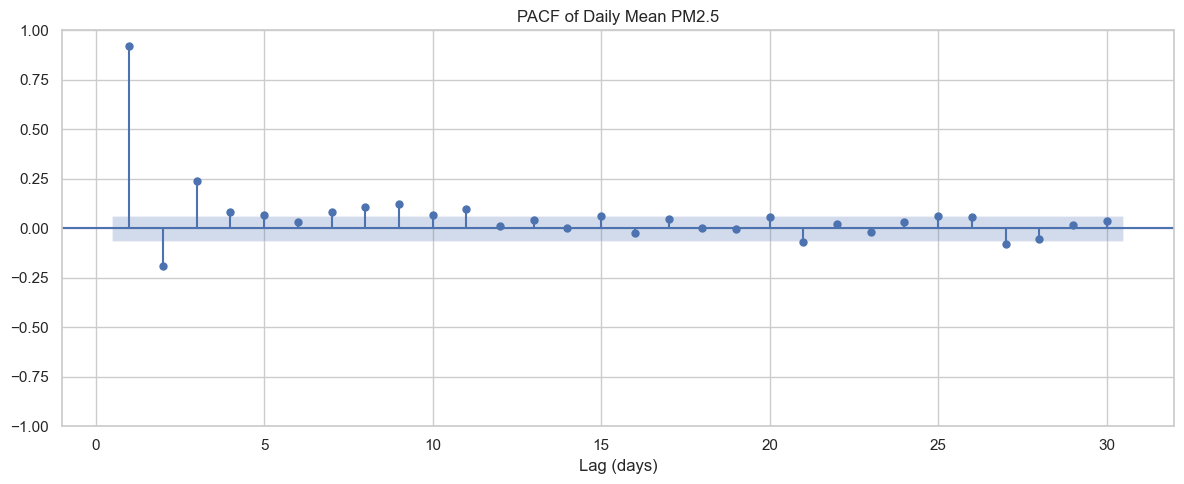

In [23]:
#Daily PACF
fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_pacf(
    daily_pm25,
    lags=30,
    method='ywm',
    zero=False,
    ax=ax
)

ax.set_title(
    'PACF of Daily Mean PM2.5'
)

ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

## Season-specific persistence

In [24]:
season_order = [
    'Winter',
    'Pre-Monsoon',
    'Monsoon',
    'Post-Monsoon'
]

hourly['season'] = pd.Categorical(
    hourly['season'],
    categories=season_order,
    ordered=True
)

In [25]:
#lag values
season_persistence_data = pd.DataFrame(
    index=hourly.index
)

season_persistence_data['pm25'] = (
    hourly['pm25']
)

season_persistence_data['season'] = (
    hourly['season']
)

for lag in [1, 6, 24, 168]:

    season_persistence_data[
        f'lag_{lag}'
    ] = hourly['pm25'].shift(lag)

In [56]:
season_persistence_results = []

lags = [1, 6, 24, 168]

for lag in lags:

    temp = pd.DataFrame({
        'pm25': hourly['pm25'],
        'season': hourly['season'],
        'lag_pm25': hourly['pm25'].shift(lag),
        'lag_season': hourly['season'].shift(lag)
    })

    for season in season_order:

        subset = temp[
            (temp['season'] == season) &
            (temp['lag_season'] == season)
        ]

        corr = subset[
            'pm25'
        ].corr(
            subset['lag_pm25']
        )

        season_persistence_results.append({
            'season': season,
            'lag_hours': lag,
            'correlation': corr
        })


season_persistence = pd.DataFrame(
    season_persistence_results
)

season_persistence_table = (
    season_persistence
    .pivot(
        index='season',
        columns='lag_hours',
        values='correlation'
    )
    .reindex(season_order)
)

season_persistence_table.round(3)

lag_hours,1,6,24,168
season,,,,
Winter,0.934,0.400,0.869,0.721
Pre-Monsoon,0.965,0.656,0.745,0.244
Monsoon,0.969,0.759,0.739,0.477
Post-Monsoon,0.979,0.751,0.872,0.542


In [27]:
season_persistence_table = (
    season_persistence
    .pivot(
        index='season',
        columns='lag_hours',
        values='correlation'
    )
    .reindex(season_order)
)

season_persistence_table.round(3)

lag_hours,1,6,24,168
season,,,,
Winter,0.934,0.400,0.869,0.712
Pre-Monsoon,0.965,0.657,0.738,0.289
Monsoon,0.969,0.760,0.743,0.482
Post-Monsoon,0.979,0.752,0.872,0.577


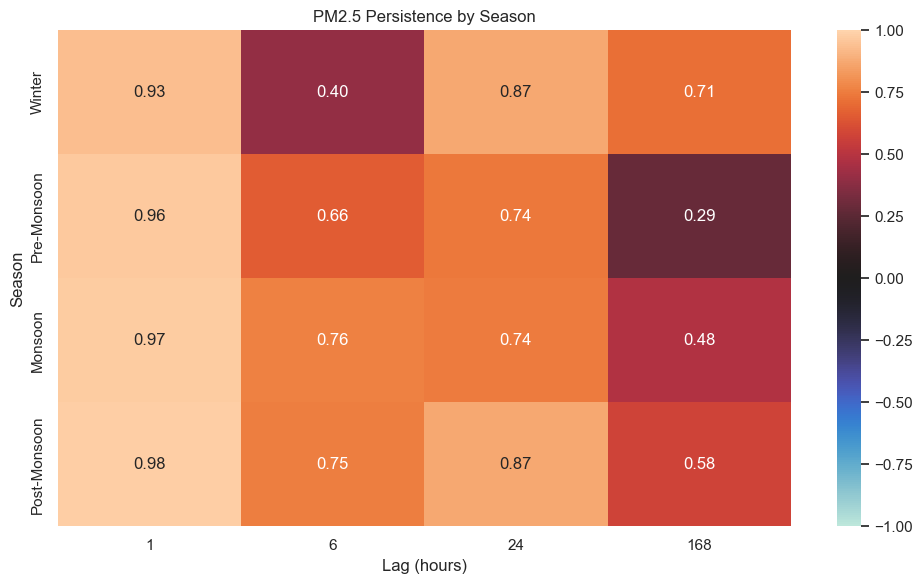

In [28]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_persistence_table,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    'PM2.5 Persistence by Season'
)

plt.xlabel('Lag (hours)')
plt.ylabel('Season')

plt.tight_layout()
plt.show()

## Rolling persistence

In [29]:
def rolling_autocorr(series):
    return pd.Series(series).autocorr(lag=1)

In [30]:
rolling_lag1 = (
    daily_pm25
    .rolling(
        window=60,
        min_periods=45
    )
    .apply(
        rolling_autocorr,
        raw=False
    )
)

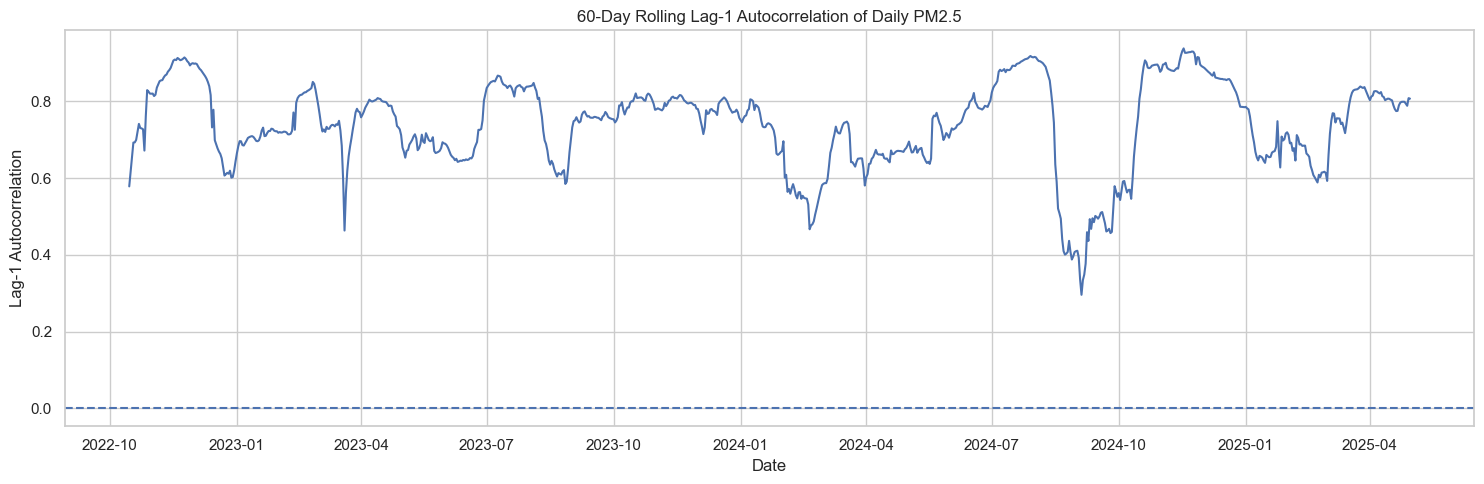

In [31]:
plt.figure(figsize=(15, 5))

plt.plot(
    rolling_lag1.index,
    rolling_lag1
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    '60-Day Rolling Lag-1 Autocorrelation of Daily PM2.5'
)

plt.xlabel('Date')
plt.ylabel('Lag-1 Autocorrelation')

plt.tight_layout()
plt.show()

## Stationarity

In [32]:
#stationarity function
def stationarity_tests(series, name):

    series = series.dropna()

    # -----------------------
    # ADF
    # -----------------------

    adf_result = adfuller(
        series,
        autolag='AIC'
    )

    # -----------------------
    # KPSS
    # -----------------------

    kpss_result = kpss(
        series,
        regression='c',
        nlags='auto'
    )

    result = pd.DataFrame({
        'test': [
            'ADF',
            'KPSS'
        ],

        'statistic': [
            adf_result[0],
            kpss_result[0]
        ],

        'p_value': [
            adf_result[1],
            kpss_result[1]
        ],

        'series': [
            name,
            name
        ]
    })

    return result

In [33]:
stationarity_raw = stationarity_tests(
    daily_pm25,
    'Daily PM2.5'
)

stationarity_raw

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(
/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(
/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:19: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after

,test,statistic,p_value,series
0,ADF,-2.770908,0.062551,Daily PM2.5
1,KPSS,0.779302,0.010000,Daily PM2.5


In [34]:
daily_pm25_diff = (
    daily_pm25
    .diff()
    .dropna()
)

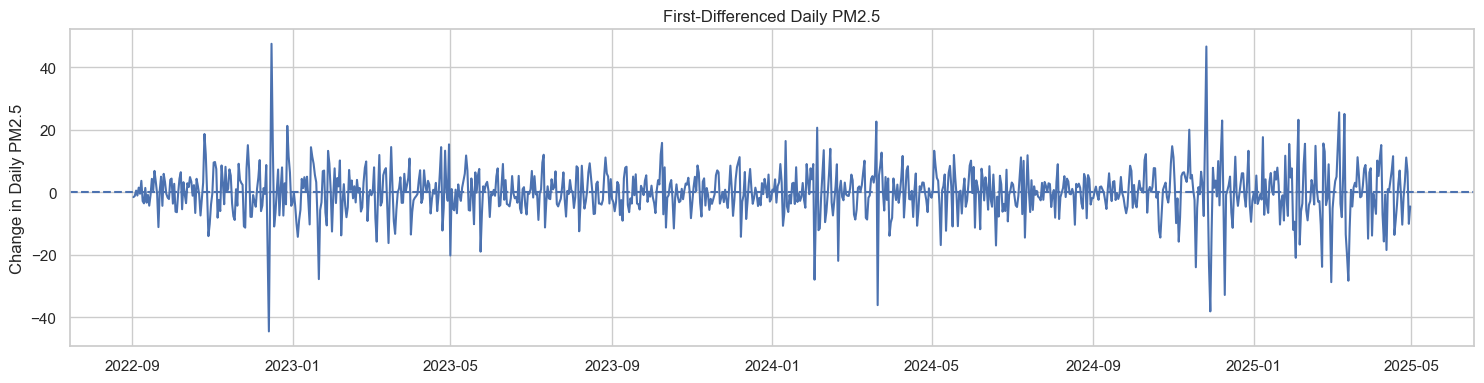

In [35]:
plt.figure(figsize=(15, 4))

plt.plot(
    daily_pm25_diff.index,
    daily_pm25_diff
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'First-Differenced Daily PM2.5'
)

plt.ylabel(
    'Change in Daily PM2.5'
)

plt.tight_layout()
plt.show()

In [36]:
#Test differenced PM2.5
stationarity_diff = stationarity_tests(
    daily_pm25_diff,
    'First-Differenced Daily PM2.5'
)

stationarity_diff

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(
/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(
/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_74454/2198559243.py:19: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after

,test,statistic,p_value,series
0,ADF,-15.910286,8.138378e-29,First-Differenced Daily PM2.5
1,KPSS,0.043392,1.000000e-01,First-Differenced Daily PM2.5


In [37]:
stationarity_results = pd.concat(
    [
        stationarity_raw,
        stationarity_diff
    ],
    ignore_index=True
)

stationarity_results

,test,statistic,p_value,series
0,ADF,-2.770908,6.255094e-02,Daily PM2.5
1,KPSS,0.779302,1.000000e-02,Daily PM2.5
2,ADF,-15.910286,8.138378e-29,First-Differenced Daily PM2.5
3,KPSS,0.043392,1.000000e-01,First-Differenced Daily PM2.5


## STL decomposition

In [38]:
hourly_stl = STL(
    hourly_pm25,
    period=24,
    robust=True
)

hourly_stl_result = (
    hourly_stl.fit()
)

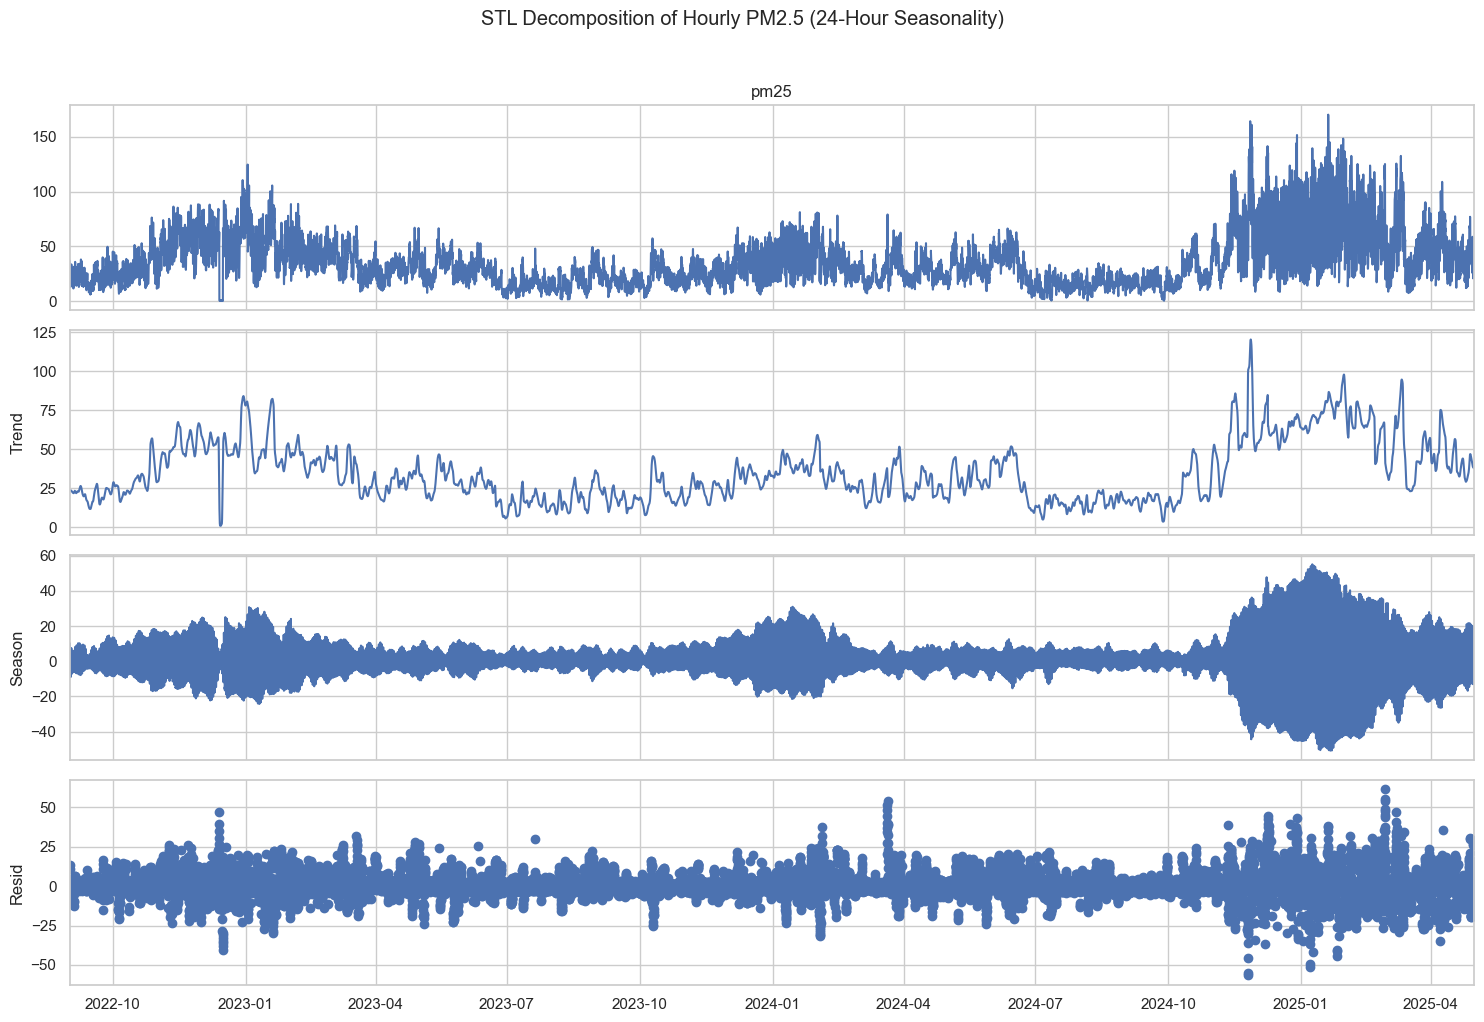

In [39]:
fig = (
    hourly_stl_result
    .plot()
)

fig.set_size_inches(
    15,
    10
)

plt.suptitle(
    'STL Decomposition of Hourly PM2.5 '
    '(24-Hour Seasonality)',
    y=1.02
)

plt.tight_layout()
plt.show()

In [40]:
#Examine extracted components
hourly_stl_components = pd.DataFrame({
    'observed':
        hourly_pm25,

    'trend':
        hourly_stl_result.trend,

    'seasonal':
        hourly_stl_result.seasonal,

    'residual':
        hourly_stl_result.resid
})

hourly_stl_components.head()

,observed,trend,seasonal,residual
time,,,,
2022-09-01 00:00:00,37.1,23.555864,-0.041735,13.585872
2022-09-01 01:00:00,36.2,23.555884,1.830318,10.813798
2022-09-01 02:00:00,35.5,23.555896,8.993570,2.950534
2022-09-01 03:00:00,34.8,23.555889,10.225678,1.018433
2022-09-01 04:00:00,33.1,23.555818,9.644377,-0.100195


In [42]:
## Daily annual STL
daily_stl = STL(
    daily_pm25,
    period=365,
    robust=True
)

daily_stl_result = (
    daily_stl.fit()
)

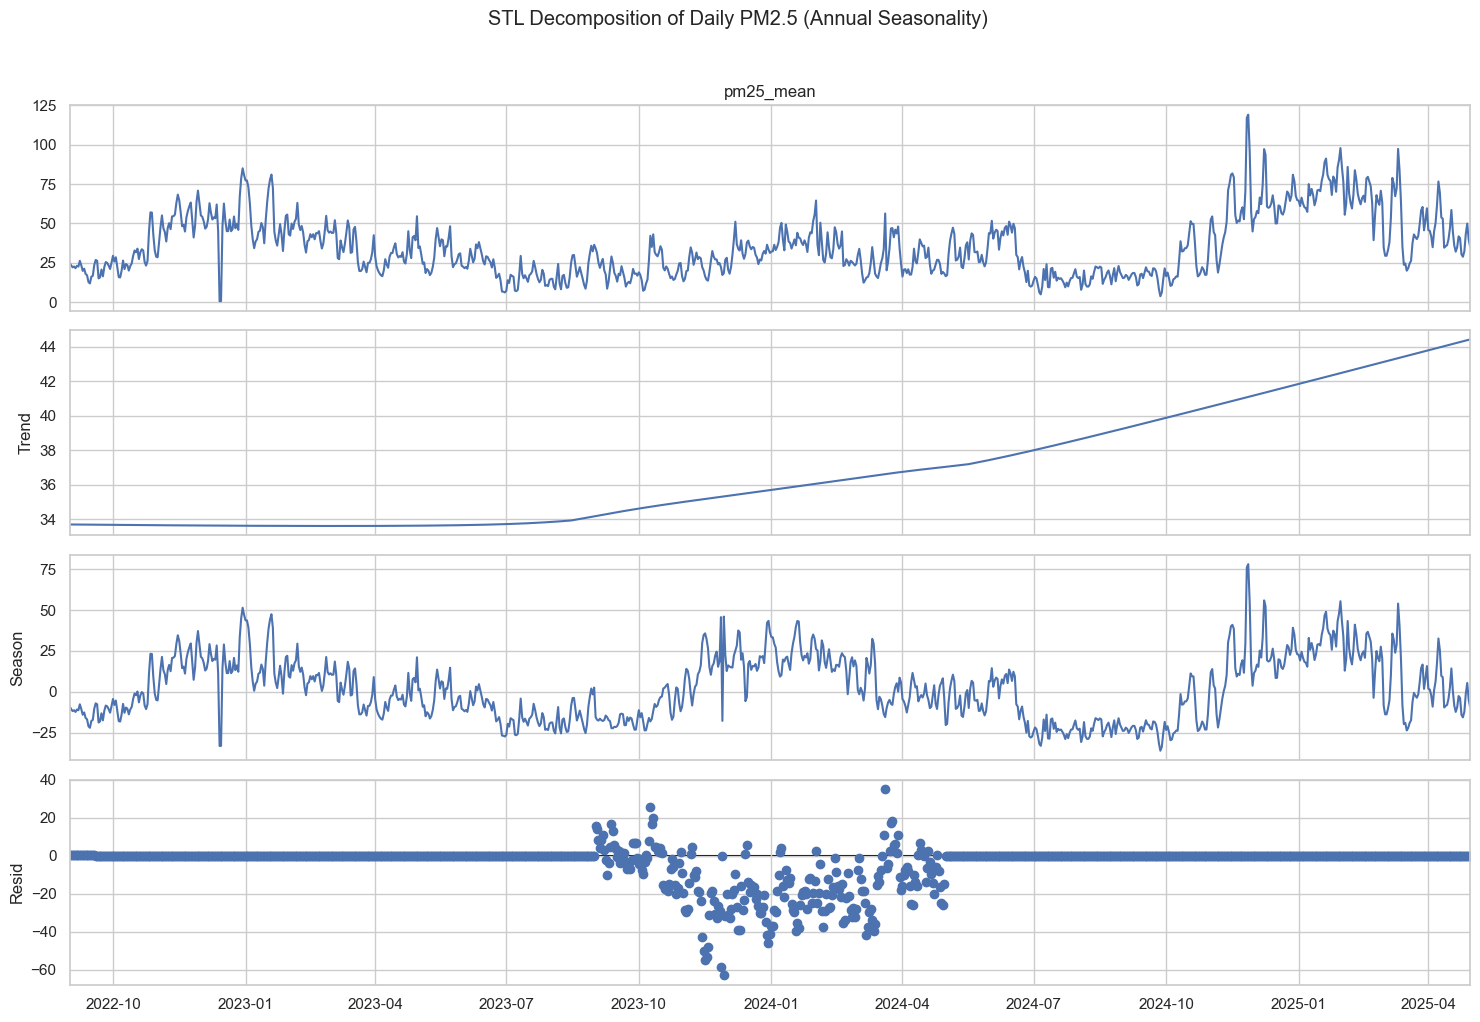

In [43]:
fig = (
    daily_stl_result
    .plot()
)

fig.set_size_inches(
    15,
    10
)

plt.suptitle(
    'STL Decomposition of Daily PM2.5 '
    '(Annual Seasonality)',
    y=1.02
)

plt.tight_layout()
plt.show()

The dataset contains fewer than three complete annual cycles. The annual STL decomposition is therefore exploratory, and its estimated annual seasonal component should be interpreted cautiously.

In [44]:
#daily STL components
daily_stl_components = pd.DataFrame({
    'observed':
        daily_pm25,

    'trend':
        daily_stl_result.trend,

    'seasonal':
        daily_stl_result.seasonal,

    'residual':
        daily_stl_result.resid
})

daily_stl_components.head()

,observed,trend,seasonal,residual
time,,,,
2022-09-01,24.866667,33.706973,-9.014318,0.174012
2022-09-02,23.312500,33.706187,-10.566344,0.172657
2022-09-03,22.125000,33.705404,-11.751706,0.171302
2022-09-04,22.654167,33.704623,-11.220402,0.169946
2022-09-05,21.600000,33.703844,-12.272434,0.168590


In [45]:
#Quantify component variability
stl_component_std = pd.Series({
    'Observed':
        daily_stl_components[
            'observed'
        ].std(),

    'Trend':
        daily_stl_components[
            'trend'
        ].std(),

    'Seasonal':
        daily_stl_components[
            'seasonal'
        ].std(),

    'Residual':
        daily_stl_components[
            'residual'
        ].std()
})

stl_component_std

Observed    19.090764
Trend        3.349699
Seasonal    19.307747
Residual    10.074426
dtype: float64

In [46]:
#Advanced optional decomposition
from statsmodels.tsa.seasonal import MSTL

In [47]:
mstl = MSTL(
    hourly_pm25,
    periods=(24, 168),
    stl_kwargs={
        'robust': True
    }
)

mstl_result = mstl.fit()

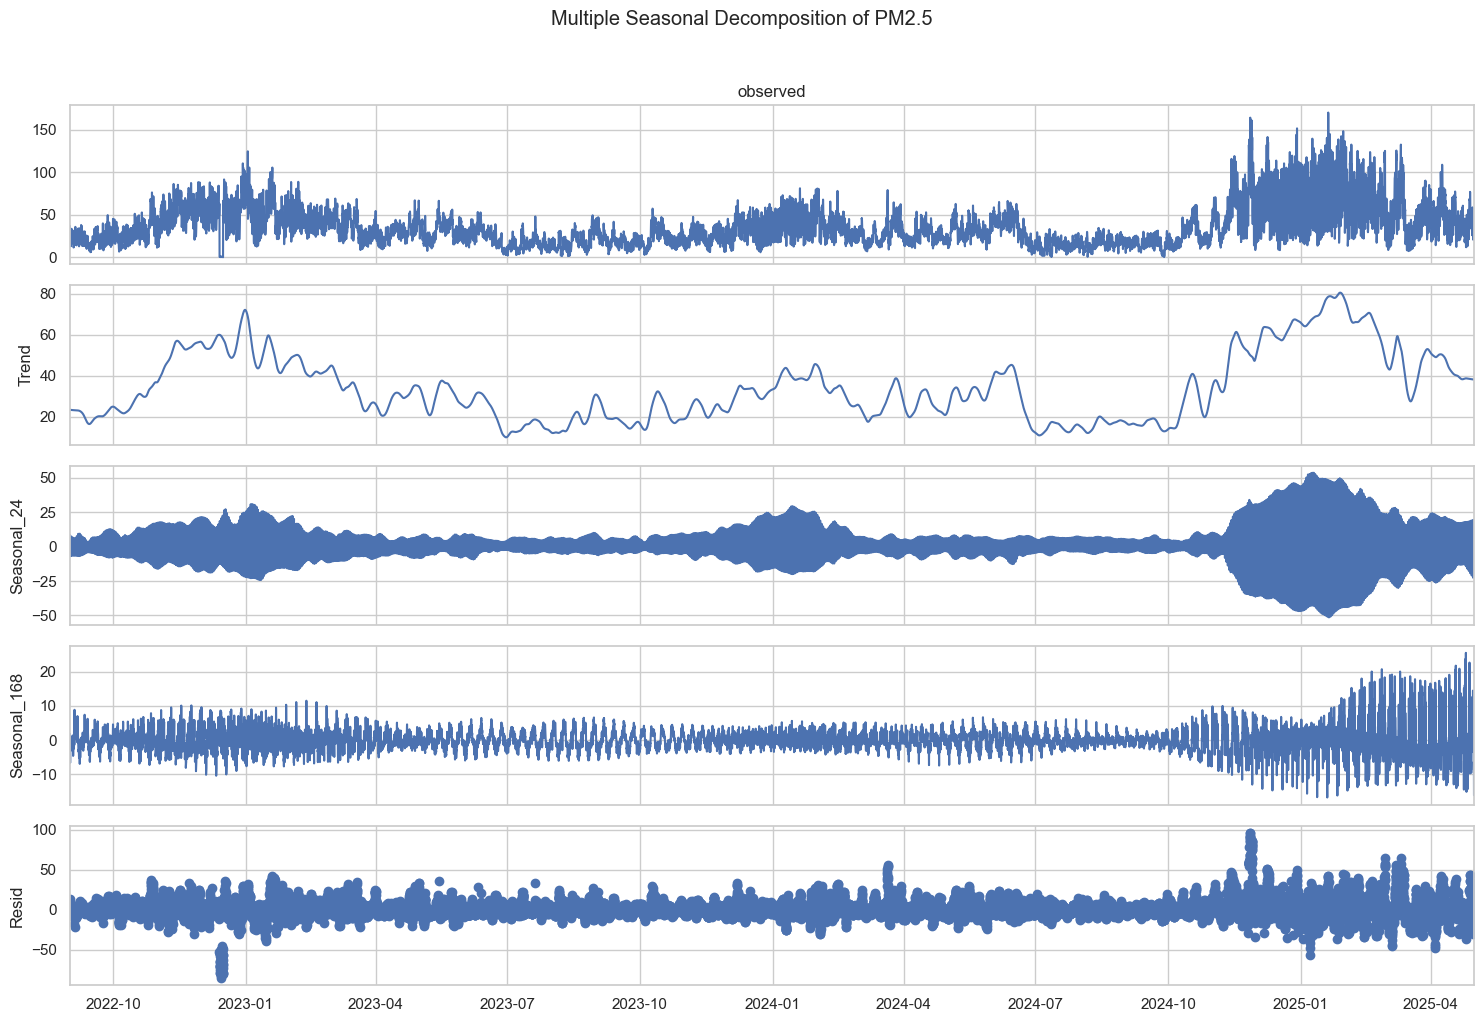

In [48]:
fig = mstl_result.plot()

fig.set_size_inches(
    15,
    10
)

plt.suptitle(
    'Multiple Seasonal Decomposition of PM2.5',
    y=1.02
)

plt.tight_layout()
plt.show()

## Ljung–Box test
Lag correlation graphs visually indicate serial dependence.
Null hypothesis:
The series has no autocorrelation up to the specified lag.

In [49]:
ljung_box_raw = acorr_ljungbox(
    daily_pm25,
    lags=[
        1,
        7,
        14,
        30
    ],
    return_df=True
)

ljung_box_raw

,lb_stat,lb_pvalue
1,823.244492,4.768475e-181
7,3864.820265,0.000000e+00
14,6966.923479,0.000000e+00
30,12695.923972,0.000000e+00


In [50]:
#Differenced PM2.5
ljung_box_diff = acorr_ljungbox(
    daily_pm25_diff,
    lags=[
        1,
        7,
        14,
        30
    ],
    return_df=True
)

ljung_box_diff

,lb_stat,lb_pvalue
1,20.035432,7.602043e-06
7,132.974357,1.501903e-25
14,147.749757,2.025051e-24
30,193.972389,6.604002e-26


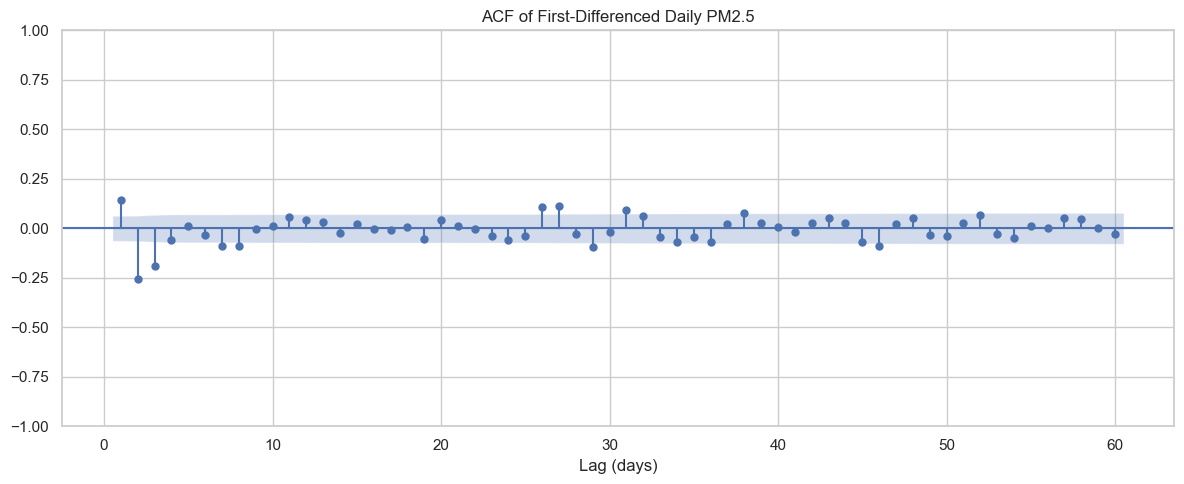

In [51]:
#raw and differenced ACF
fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_acf(
    daily_pm25_diff,
    lags=60,
    zero=False,
    ax=ax
)

ax.set_title(
    'ACF of First-Differenced Daily PM2.5'
)

ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

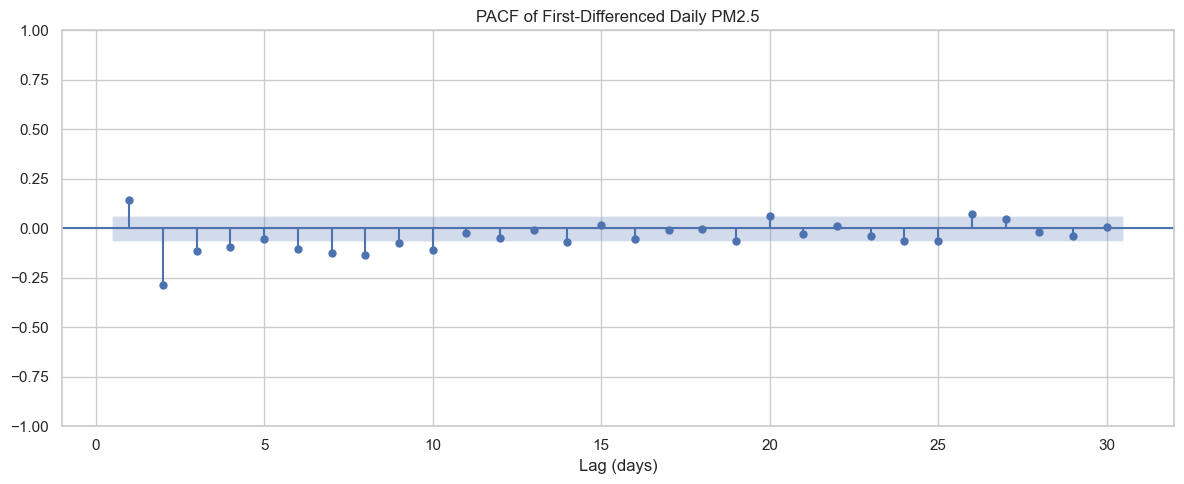

In [52]:
#PACF after differencing
fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_pacf(
    daily_pm25_diff,
    lags=30,
    method='ywm',
    zero=False,
    ax=ax
)

ax.set_title(
    'PACF of First-Differenced Daily PM2.5'
)

ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

In [53]:
hourly_lag_correlations.to_csv(
    TABLES_DIR /
    "hourly_pm25_lag_correlations.csv"
)

daily_lag_correlations.to_csv(
    TABLES_DIR /
    "daily_pm25_lag_correlations.csv"
)

season_persistence_table.to_csv(
    TABLES_DIR /
    "seasonal_pm25_persistence.csv"
)

stationarity_results.to_csv(
    TABLES_DIR /
    "stationarity_tests.csv",
    index=False
)

ljung_box_raw.to_csv(
    TABLES_DIR /
    "ljung_box_daily_raw.csv"
)

ljung_box_diff.to_csv(
    TABLES_DIR /
    "ljung_box_daily_differenced.csv"
)

In [54]:
print("=" * 72)
print("PHASE 5 — TIME-SERIES ANALYSIS SUMMARY")
print("=" * 72)

print("\nHOURLY LAG CORRELATIONS")
print(
    hourly_lag_correlations
    .round(3)
)

print("\nDAILY LAG CORRELATIONS")
print(
    daily_lag_correlations
    .round(3)
)

print("\nSEASON-SPECIFIC PERSISTENCE")
print(
    season_persistence_table
    .round(3)
)

print("\nSTATIONARITY TESTS")
print(
    stationarity_results
    .round(4)
)

print("\nLJUNG-BOX — RAW DAILY PM2.5")
print(
    ljung_box_raw
)

print(
    "\nLJUNG-BOX — DIFFERENCED DAILY PM2.5"
)

print(
    ljung_box_diff
)

print(
    "\nSTL COMPONENT STANDARD DEVIATIONS"
)

print(
    stl_component_std
    .round(3)
)

print("\n" + "=" * 72)

PHASE 5 — TIME-SERIES ANALYSIS SUMMARY

HOURLY LAG CORRELATIONS
           correlation description
lag_hours                         
1                0.965      1 hour
3                0.848     3 hours
6                0.666     6 hours
12               0.461    12 hours
24               0.877       1 day
48               0.801      2 days
72               0.753      3 days
168              0.687      1 week

DAILY LAG CORRELATIONS
          correlation
lag_days             
1               0.919
2               0.814
3               0.751
7               0.656
14              0.667
30              0.557
60              0.330

SEASON-SPECIFIC PERSISTENCE
lag_hours       1      6      24     168
season                                  
Winter        0.934  0.400  0.869  0.712
Pre-Monsoon   0.965  0.657  0.738  0.289
Monsoon       0.969  0.760  0.743  0.482
Post-Monsoon  0.979  0.752  0.872  0.577

STATIONARITY TESTS
   test  statistic  p_value                         series
0   ADF   

| ADF | KPSS | Likely interpretation |
|---|---|---|
| Reject H₀ | Fail to reject H₀ | Evidence for stationarity |
| Fail to reject H₀ | Reject H₀ | Evidence for non-stationarity |
| Reject H₀ | Reject H₀ | Possibly trend/seasonal/structural complexity |
| Fail to reject H₀ | Fail to reject H₀ | Inconclusive |

In [55]:
print(hourly_lag_correlations.round(3))

print(daily_lag_correlations.round(3))

print(season_persistence_table.round(3))

print(stationarity_results.round(4))

print(ljung_box_raw)

print(ljung_box_diff)

print(stl_component_std.round(3))

           correlation description
lag_hours                         
1                0.965      1 hour
3                0.848     3 hours
6                0.666     6 hours
12               0.461    12 hours
24               0.877       1 day
48               0.801      2 days
72               0.753      3 days
168              0.687      1 week
          correlation
lag_days             
1               0.919
2               0.814
3               0.751
7               0.656
14              0.667
30              0.557
60              0.330
lag_hours       1      6      24     168
season                                  
Winter        0.934  0.400  0.869  0.712
Pre-Monsoon   0.965  0.657  0.738  0.289
Monsoon       0.969  0.760  0.743  0.482
Post-Monsoon  0.979  0.752  0.872  0.577
   test  statistic  p_value                         series
0   ADF    -2.7709   0.0626                    Daily PM2.5
1  KPSS     0.7793   0.0100                    Daily PM2.5
2   ADF   -15.9103   0.0000  

## Phase 5 Summary: Time-Series Analysis

PM2.5 concentrations exhibited strong temporal dependence across both
hourly and daily timescales. Hourly PM2.5 had a lag-1 correlation of
approximately 0.965, demonstrating very strong persistence between
consecutive hours. Correlation decreased across intermediate lags but
increased again substantially at a 24-hour lag (approximately 0.877),
indicating a pronounced diurnal cycle. The hourly autocorrelation
function similarly displayed recurring peaks at approximately 24-hour
intervals.

Daily PM2.5 was also highly persistent. The lag-1 daily correlation was
approximately 0.919, while correlations remained approximately 0.656 at
seven days, 0.557 at 30 days, and 0.330 at 60 days. These longer-lag
relationships likely reflect a combination of persistent pollution
episodes and slower seasonal variation rather than individual pollution
events lasting for several weeks.

Persistence differed across climatological seasons. Winter exhibited
particularly strong 24-hour and one-week persistence, while monsoon and
post-monsoon periods exhibited stronger short-term within-day
persistence. Rolling autocorrelation additionally showed that the degree
of day-to-day persistence varied over the study period rather than
remaining constant.

Stationarity tests indicated that the raw daily PM2.5 series was
non-stationary. At the 5% significance level, the Augmented Dickey-Fuller
test failed to reject the unit-root null hypothesis, while the KPSS test
rejected stationarity. After first differencing, the ADF test strongly
rejected the unit-root null and the KPSS test no longer rejected
stationarity, providing evidence that first differencing produced a
stationary series.

Ljung-Box tests nevertheless remained statistically significant after
first differencing, demonstrating that stationarity did not eliminate
serial dependence. The differenced ACF and PACF similarly showed weaker
but remaining temporal structure, suggesting that lagged information
continues to contain potential predictive value.

Multiple-seasonal decomposition of the hourly series identified a strong
24-hour seasonal component and a smaller weekly component. Together,
these findings demonstrate that Kathmandu PM2.5 is characterized by
strong short-term persistence, pronounced daily periodicity, longer-term
seasonal dependence, and time-varying autocorrelation. These properties
will be considered explicitly when constructing later statistical and
machine-learning forecasting models.